# Comparación de los tests CROHME 2014 — Modelo1 vs. Modelo2

Este notebook compara de forma pareada los dos tests analizados previamente:

| Fuente | Imágenes | Anotaciones |
|---|---|---|
| Modelo1 | \`data/Modelo1/2014/14_test_images/*.bmp\` | \`test_caption.txt\` |
| Modelo2 | \`data/Modelo2/2014/img/*.bmp\` | \`caption.txt\` |

El objetivo es distinguir cuatro tipos de diferencia:

1. **Inventario y correspondencia**: IDs presentes y orden de las muestras.
2. **Representación de archivos**: nombres, tamaños, hash y contenido de píxeles.
3. **Anotaciones**: cadenas, secuencias de tokens y operaciones de edición.
4. **Distribución del vocabulario**: frecuencias, proporciones y tokens responsables del cambio.

La comparación es descriptiva: no modifica ninguno de los datasets.


## Criterios de comparación

- El identificador canónico es el ID de la anotación.
- En Modelo1 se elimina únicamente el sufijo técnico \`_0\` del nombre del BMP.
- Dos imágenes con el mismo SHA-256 son idénticas byte a byte. Si el hash difiere, también se comparan dimensiones, modo y píxeles.
- Las anotaciones se comparan en tres niveles: texto exacto, espacios normalizados y tokens separados por espacios.
- Se calcula una distancia de Levenshtein sobre tokens y se identifican inserciones, eliminaciones y sustituciones.
- El orden de las filas se estudia por separado del contenido; un reordenamiento no se considera una diferencia semántica.


In [1]:
from pathlib import Path
from collections import Counter
from difflib import SequenceMatcher
import hashlib
import json
import math
import re
import textwrap

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
plt.style.use("ggplot")
RANDOM_SEED = 42


In [2]:
def localizar_raiz(inicio: Path) -> Path:
    inicio = inicio.resolve()
    for raiz in [inicio, *inicio.parents]:
        requerido = [
            raiz / "data" / "Modelo1" / "2014" / "test_caption.txt",
            raiz / "data" / "Modelo2" / "2014" / "caption.txt",
        ]
        if all(ruta.is_file() for ruta in requerido):
            return raiz
    raise FileNotFoundError(
        "No se encontraron ambos tests. Ejecuta el notebook dentro del repositorio."
    )

RAIZ = localizar_raiz(Path.cwd())
M1_DIR = RAIZ / "data" / "Modelo1" / "2014"
M2_DIR = RAIZ / "data" / "Modelo2" / "2014"
M1_IMG_DIR = M1_DIR / "14_test_images"
M2_IMG_DIR = M2_DIR / "img"
M1_CAPTION = M1_DIR / "test_caption.txt"
M2_CAPTION = M2_DIR / "caption.txt"
RESULTADOS_DIR = RAIZ / "Cascada" / "00_analisis_exploratorio" / "resultados"
RESULTADOS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz: {RAIZ}")
print(f"Modelo1: {M1_DIR.relative_to(RAIZ)}")
print(f"Modelo2: {M2_DIR.relative_to(RAIZ)}")


Raíz: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas
Modelo1: data\Modelo1\2014
Modelo2: data\Modelo2\2014


## 1. Inventario, IDs y orden

Primero se comprueba si ambos tests contienen el mismo conjunto de muestras. Después se compara la posición de cada ID en los archivos de anotaciones para detectar simples reordenamientos.


In [3]:
def leer_captions(ruta: Path, modelo: str) -> pd.DataFrame:
    registros = []
    with ruta.open("r", encoding="utf-8-sig") as archivo:
        for posicion, linea in enumerate(archivo):
            linea = linea.rstrip("\r\n")
            if not linea.strip():
                continue
            if "\t" not in linea:
                raise ValueError(f"{ruta.name}, línea {posicion + 1}: falta tabulación")
            identificador, latex = linea.split("\t", maxsplit=1)
            registros.append(
                {
                    "id": identificador.strip(),
                    f"latex_{modelo}": latex.strip(),
                    f"posicion_{modelo}": posicion,
                }
            )
    tabla = pd.DataFrame(registros)
    if tabla["id"].duplicated().any():
        repetidos = tabla.loc[tabla["id"].duplicated(keep=False), "id"].tolist()
        raise ValueError(f"IDs duplicados en {modelo}: {repetidos[:10]}")
    return tabla

cap_m1 = leer_captions(M1_CAPTION, "modelo1")
cap_m2 = leer_captions(M2_CAPTION, "modelo2")

img_m1 = sorted(M1_IMG_DIR.glob("*.bmp"))
img_m2 = sorted(M2_IMG_DIR.glob("*.bmp"))

mapa_img_m1 = {re.sub(r"_0$", "", ruta.stem): ruta for ruta in img_m1}
mapa_img_m2 = {ruta.stem: ruta for ruta in img_m2}

ids_cap_m1 = set(cap_m1["id"])
ids_cap_m2 = set(cap_m2["id"])
ids_img_m1 = set(mapa_img_m1)
ids_img_m2 = set(mapa_img_m2)
todos_ids = sorted(ids_cap_m1 | ids_cap_m2 | ids_img_m1 | ids_img_m2)

inventario = pd.Series(
    {
        "anotaciones Modelo1": len(cap_m1),
        "anotaciones Modelo2": len(cap_m2),
        "BMP Modelo1": len(img_m1),
        "BMP Modelo2": len(img_m2),
        "IDs comunes en los cuatro inventarios": len(
            ids_cap_m1 & ids_cap_m2 & ids_img_m1 & ids_img_m2
        ),
        "IDs en la unión": len(todos_ids),
        "solo anotaciones Modelo1": len(ids_cap_m1 - ids_cap_m2),
        "solo anotaciones Modelo2": len(ids_cap_m2 - ids_cap_m1),
        "solo imágenes Modelo1": len(ids_img_m1 - ids_img_m2),
        "solo imágenes Modelo2": len(ids_img_m2 - ids_img_m1),
    },
    name="cantidad",
).to_frame()
display(inventario)


,cantidad
anotaciones Modelo1,986
anotaciones Modelo2,986
BMP Modelo1,986
BMP Modelo2,986
IDs comunes en los cuatro inventarios,986
IDs en la unión,986
solo anotaciones Modelo1,0
solo anotaciones Modelo2,0
solo imágenes Modelo1,0
solo imágenes Modelo2,0


,valor
IDs en la misma posición,0.0000
IDs reordenados,986.0000
desplazamiento absoluto mediano,274.0000
desplazamiento absoluto máximo,978.0000
correlación de posiciones (Spearman),0.0282


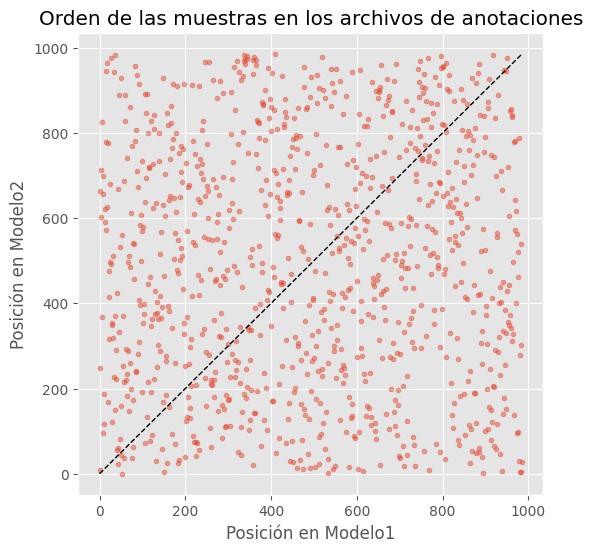

In [4]:
comparacion = cap_m1.merge(cap_m2, on="id", how="outer", validate="one_to_one")
comparacion["misma_posicion"] = (
    comparacion["posicion_modelo1"] == comparacion["posicion_modelo2"]
)
comparacion["desplazamiento_posicion"] = (
    comparacion["posicion_modelo2"] - comparacion["posicion_modelo1"]
)

orden = pd.Series(
    {
        "IDs en la misma posición": int(comparacion["misma_posicion"].sum()),
        "IDs reordenados": int((~comparacion["misma_posicion"]).sum()),
        "desplazamiento absoluto mediano": comparacion[
            "desplazamiento_posicion"
        ].abs().median(),
        "desplazamiento absoluto máximo": comparacion[
            "desplazamiento_posicion"
        ].abs().max(),
        "correlación de posiciones (Spearman)": comparacion[
            ["posicion_modelo1", "posicion_modelo2"]
        ].corr(method="spearman").iloc[0, 1],
    },
    name="valor",
).to_frame()
display(orden.round(4))

fig, eje = plt.subplots(figsize=(6, 6))
eje.scatter(
    comparacion["posicion_modelo1"],
    comparacion["posicion_modelo2"],
    s=12,
    alpha=0.5,
)
limite = max(len(cap_m1), len(cap_m2))
eje.plot([0, limite], [0, limite], "--", color="black", linewidth=1)
eje.set(
    xlabel="Posición en Modelo1",
    ylabel="Posición en Modelo2",
    title="Orden de las muestras en los archivos de anotaciones",
)
plt.show()


## 2. Comparación del contenido de las imágenes

Se calcula SHA-256 para detectar igualdad exacta de archivos. Para cualquier par con hashes distintos, se abre el BMP y se comprueba si la matriz de píxeles sigue siendo idéntica; esto separa cambios de metadatos/serialización de cambios visuales reales.


In [5]:
def sha256_archivo(ruta: Path, bloque: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with ruta.open("rb") as archivo:
        while True:
            fragmento = archivo.read(bloque)
            if not fragmento:
                break
            digest.update(fragmento)
    return digest.hexdigest()

def describir_imagen(ruta: Path) -> dict:
    with Image.open(ruta) as imagen:
        ancho, alto = imagen.size
        return {
            "ancho": ancho,
            "alto": alto,
            "modo": imagen.mode,
            "formato": imagen.format,
            "bytes": ruta.stat().st_size,
        }

def comparar_pixeles(ruta1: Path, ruta2: Path) -> dict:
    try:
        with Image.open(ruta1) as im1, Image.open(ruta2) as im2:
            a = np.asarray(im1.convert("L"), dtype=np.int16)
            b = np.asarray(im2.convert("L"), dtype=np.int16)
        if a.shape != b.shape:
            return {
                "misma_forma_pixeles": False,
                "pixeles_iguales": False,
                "mae_pixeles": np.nan,
                "max_diferencia_pixel": np.nan,
            }
        diferencia = np.abs(a - b)
        return {
            "misma_forma_pixeles": True,
            "pixeles_iguales": bool(np.array_equal(a, b)),
            "mae_pixeles": float(diferencia.mean()),
            "max_diferencia_pixel": int(diferencia.max()),
        }
    except (OSError, ValueError, UnidentifiedImageError) as exc:
        return {
            "misma_forma_pixeles": False,
            "pixeles_iguales": False,
            "mae_pixeles": np.nan,
            "max_diferencia_pixel": np.nan,
            "error_comparacion": f"{type(exc).__name__}: {exc}",
        }


In [6]:
registros_imagen = []
ids_imagen_comunes = sorted(ids_img_m1 & ids_img_m2)

for identificador in ids_imagen_comunes:
    ruta1 = mapa_img_m1[identificador]
    ruta2 = mapa_img_m2[identificador]
    meta1 = describir_imagen(ruta1)
    meta2 = describir_imagen(ruta2)
    hash1 = sha256_archivo(ruta1)
    hash2 = sha256_archivo(ruta2)
    hash_igual = hash1 == hash2

    if hash_igual:
        comparacion_pixel = {
            "misma_forma_pixeles": True,
            "pixeles_iguales": True,
            "mae_pixeles": 0.0,
            "max_diferencia_pixel": 0,
        }
    else:
        comparacion_pixel = comparar_pixeles(ruta1, ruta2)

    registros_imagen.append(
        {
            "id": identificador,
            "archivo_modelo1": ruta1.name,
            "archivo_modelo2": ruta2.name,
            "bytes_modelo1": meta1["bytes"],
            "bytes_modelo2": meta2["bytes"],
            "ancho_modelo1": meta1["ancho"],
            "alto_modelo1": meta1["alto"],
            "ancho_modelo2": meta2["ancho"],
            "alto_modelo2": meta2["alto"],
            "modo_modelo1": meta1["modo"],
            "modo_modelo2": meta2["modo"],
            "sha256_modelo1": hash1,
            "sha256_modelo2": hash2,
            "hash_igual": hash_igual,
            **comparacion_pixel,
        }
    )

comparacion_imagenes = pd.DataFrame(registros_imagen)
comparacion_imagenes["mismas_dimensiones"] = (
    (comparacion_imagenes["ancho_modelo1"] == comparacion_imagenes["ancho_modelo2"])
    & (comparacion_imagenes["alto_modelo1"] == comparacion_imagenes["alto_modelo2"])
)
comparacion_imagenes["mismo_tamano_bytes"] = (
    comparacion_imagenes["bytes_modelo1"] == comparacion_imagenes["bytes_modelo2"]
)

resumen_imagenes = pd.Series(
    {
        "pares comparados": len(comparacion_imagenes),
        "mismo nombre de archivo": int(
            (comparacion_imagenes["archivo_modelo1"]
             == comparacion_imagenes["archivo_modelo2"]).sum()
        ),
        "mismo tamaño en bytes": int(comparacion_imagenes["mismo_tamano_bytes"].sum()),
        "mismas dimensiones": int(comparacion_imagenes["mismas_dimensiones"].sum()),
        "mismo SHA-256": int(comparacion_imagenes["hash_igual"].sum()),
        "mismos píxeles": int(comparacion_imagenes["pixeles_iguales"].sum()),
        "contenido visual diferente": int(
            (~comparacion_imagenes["pixeles_iguales"]).sum()
        ),
    },
    name="cantidad",
).to_frame()
display(resumen_imagenes)
display(
    comparacion_imagenes.loc[
        ~comparacion_imagenes["hash_igual"],
        [
            "id", "archivo_modelo1", "archivo_modelo2",
            "mismas_dimensiones", "pixeles_iguales",
            "mae_pixeles", "max_diferencia_pixel",
        ],
    ].head(20)
)


,cantidad
pares comparados,986
mismo nombre de archivo,0
mismo tamaño en bytes,986
mismas dimensiones,986
mismo SHA-256,986
mismos píxeles,986
contenido visual diferente,0


,id,archivo_modelo1,archivo_modelo2,mismas_dimensiones,pixeles_iguales,mae_pixeles,max_diferencia_pixel


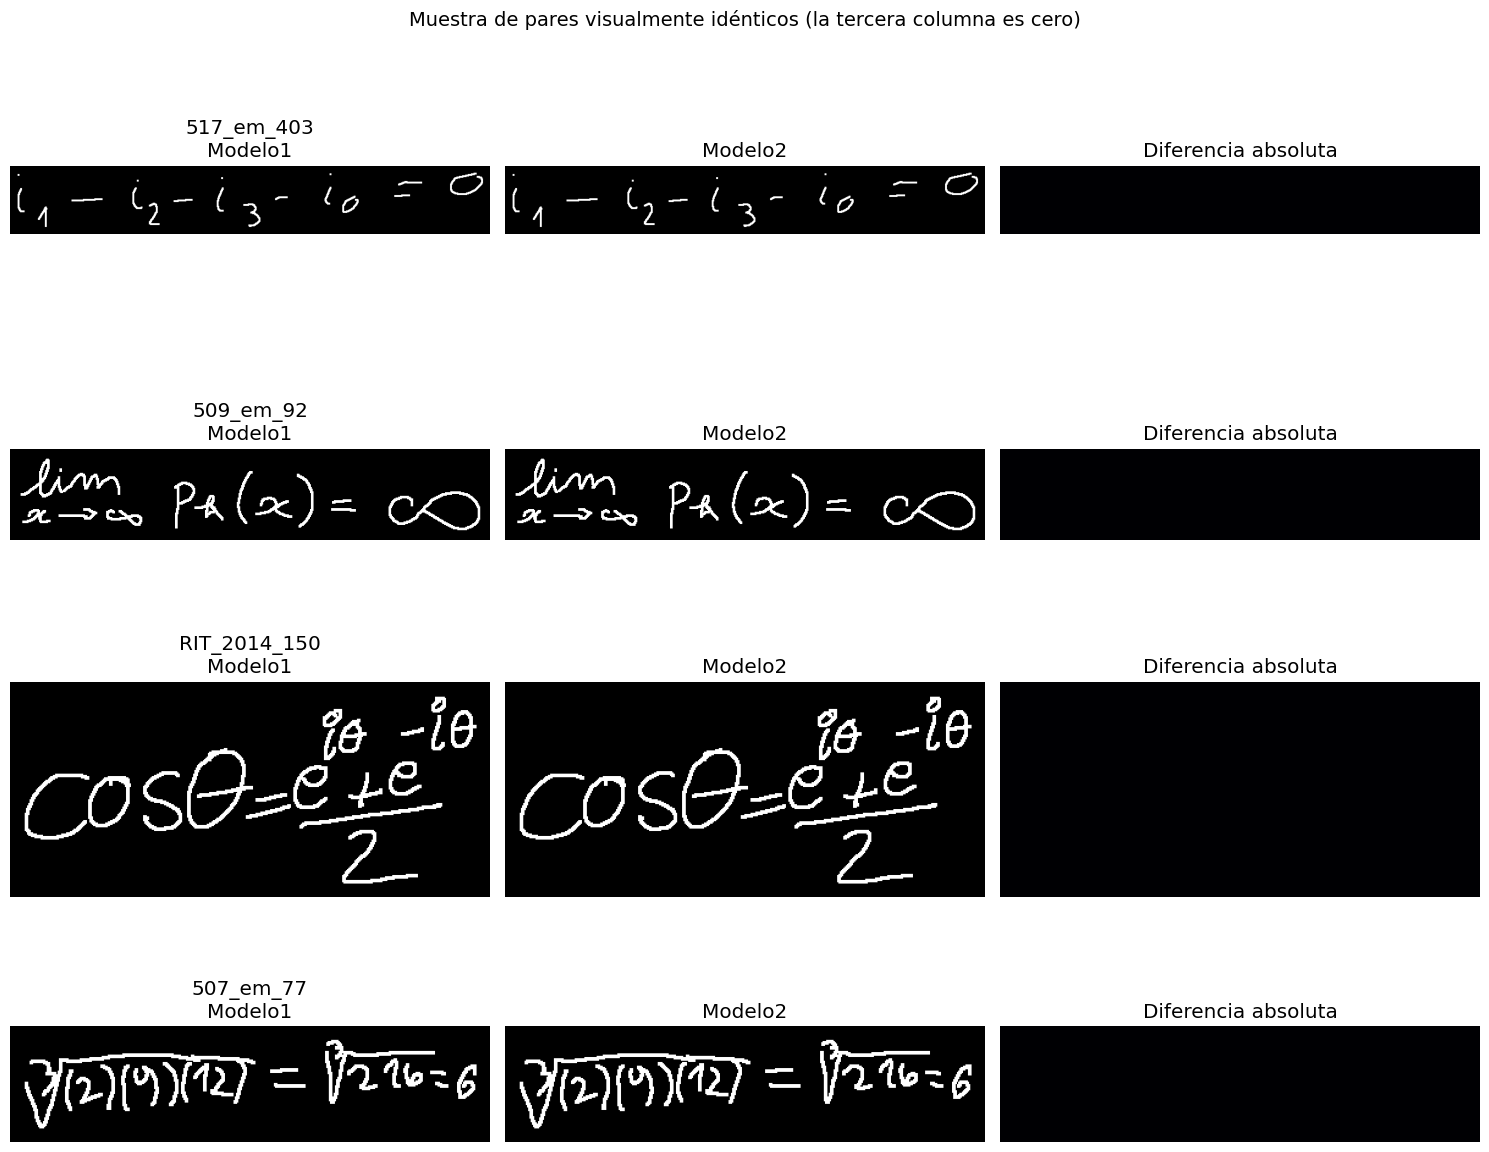

In [7]:
def mostrar_pares_imagen(ids, titulo, n=6):
    ids = list(ids)[:n]
    if not ids:
        print("No hay pares en esta categoría.")
        return
    fig, ejes = plt.subplots(len(ids), 3, figsize=(15, 3.2 * len(ids)))
    ejes = np.atleast_2d(ejes)
    for fila, identificador in enumerate(ids):
        with Image.open(mapa_img_m1[identificador]) as im1:
            a = np.asarray(im1.convert("L"))
        with Image.open(mapa_img_m2[identificador]) as im2:
            b = np.asarray(im2.convert("L"))
        ejes[fila, 0].imshow(a, cmap="gray", vmin=0, vmax=255)
        ejes[fila, 1].imshow(b, cmap="gray", vmin=0, vmax=255)
        if a.shape == b.shape:
            diferencia = np.abs(a.astype(np.int16) - b.astype(np.int16))
            ejes[fila, 2].imshow(diferencia, cmap="magma")
        else:
            ejes[fila, 2].text(0.5, 0.5, "Dimensiones distintas", ha="center")
        ejes[fila, 0].set_title(f"{identificador}\nModelo1")
        ejes[fila, 1].set_title("Modelo2")
        ejes[fila, 2].set_title("Diferencia absoluta")
        for eje in ejes[fila]:
            eje.axis("off")
    fig.suptitle(titulo, fontsize=14)
    fig.tight_layout()
    plt.show()

ids_visualmente_distintos = comparacion_imagenes.loc[
    ~comparacion_imagenes["pixeles_iguales"], "id"
]
if len(ids_visualmente_distintos):
    mostrar_pares_imagen(ids_visualmente_distintos, "Pares con diferencias visuales")
else:
    muestra_ids = comparacion_imagenes.sample(
        n=min(4, len(comparacion_imagenes)), random_state=RANDOM_SEED
    )["id"]
    mostrar_pares_imagen(
        muestra_ids,
        "Muestra de pares visualmente idénticos (la tercera columna es cero)",
        n=4,
    )


## 3. Comparación pareada de las anotaciones LaTeX

La distancia de Levenshtein se calcula sobre tokens. Además se usa \`SequenceMatcher\` para resumir qué tokens fueron insertados, eliminados o sustituidos. Se prueba explícitamente si retirar \`\limits\` hace equivalentes las secuencias, porque este comando modifica la presentación de límites sin cambiar el operador matemático base.


In [8]:
def normalizar_espacios(texto: str) -> str:
    return " ".join(texto.split())

def distancia_levenshtein_tokens(a, b) -> int:
    if len(a) < len(b):
        a, b = b, a
    anterior = list(range(len(b) + 1))
    for i, token_a in enumerate(a, start=1):
        actual = [i]
        for j, token_b in enumerate(b, start=1):
            actual.append(
                min(
                    actual[-1] + 1,
                    anterior[j] + 1,
                    anterior[j - 1] + (token_a != token_b),
                )
            )
        anterior = actual
    return anterior[-1]

def operaciones_tokens(a, b):
    matcher = SequenceMatcher(a=a, b=b, autojunk=False)
    operaciones = []
    for tipo, i1, i2, j1, j2 in matcher.get_opcodes():
        if tipo != "equal":
            operaciones.append(
                {
                    "operacion": tipo,
                    "tokens_modelo1": a[i1:i2],
                    "tokens_modelo2": b[j1:j2],
                }
            )
    return operaciones

comparacion["latex_modelo1"] = comparacion["latex_modelo1"].fillna("")
comparacion["latex_modelo2"] = comparacion["latex_modelo2"].fillna("")
comparacion["normalizado_modelo1"] = comparacion["latex_modelo1"].map(normalizar_espacios)
comparacion["normalizado_modelo2"] = comparacion["latex_modelo2"].map(normalizar_espacios)
comparacion["tokens_modelo1"] = comparacion["normalizado_modelo1"].map(str.split)
comparacion["tokens_modelo2"] = comparacion["normalizado_modelo2"].map(str.split)

comparacion["texto_exacto_igual"] = (
    comparacion["latex_modelo1"] == comparacion["latex_modelo2"]
)
comparacion["espacios_normalizados_iguales"] = (
    comparacion["normalizado_modelo1"] == comparacion["normalizado_modelo2"]
)
comparacion["tokens_iguales"] = (
    comparacion["tokens_modelo1"] == comparacion["tokens_modelo2"]
)
comparacion["n_tokens_modelo1"] = comparacion["tokens_modelo1"].map(len)
comparacion["n_tokens_modelo2"] = comparacion["tokens_modelo2"].map(len)
comparacion["delta_n_tokens"] = (
    comparacion["n_tokens_modelo2"] - comparacion["n_tokens_modelo1"]
)
comparacion["distancia_tokens"] = comparacion.apply(
    lambda fila: distancia_levenshtein_tokens(
        fila["tokens_modelo1"], fila["tokens_modelo2"]
    ),
    axis=1,
)
comparacion["operaciones"] = comparacion.apply(
    lambda fila: operaciones_tokens(fila["tokens_modelo1"], fila["tokens_modelo2"]),
    axis=1,
)
comparacion["iguales_sin_limits"] = comparacion.apply(
    lambda fila: [t for t in fila["tokens_modelo1"] if t != r"\limits"]
    == [t for t in fila["tokens_modelo2"] if t != r"\limits"],
    axis=1,
)


In [9]:
def clasificar_diferencia(fila) -> str:
    if fila["tokens_iguales"]:
        if fila["texto_exacto_igual"]:
            return "idéntica"
        return "solo formato/espacios"
    if fila["iguales_sin_limits"]:
        return r"solo \limits"
    return "otros cambios de tokens"

comparacion["tipo_diferencia"] = comparacion.apply(clasificar_diferencia, axis=1)
conteo_tipos = comparacion["tipo_diferencia"].value_counts().rename("cantidad").to_frame()
conteo_tipos["proporcion"] = conteo_tipos["cantidad"] / len(comparacion)

resumen_anotaciones = pd.Series(
    {
        "pares comparados": len(comparacion),
        "texto exacto igual": int(comparacion["texto_exacto_igual"].sum()),
        "secuencia de tokens igual": int(comparacion["tokens_iguales"].sum()),
        "secuencia diferente": int((~comparacion["tokens_iguales"]).sum()),
        r"diferencias explicadas al retirar \limits": int(
            ((~comparacion["tokens_iguales"]) & comparacion["iguales_sin_limits"]).sum()
        ),
        "distancia total de edición": int(comparacion["distancia_tokens"].sum()),
        "distancia máxima": int(comparacion["distancia_tokens"].max()),
        "cambio neto total de tokens (M2 - M1)": int(
            comparacion["delta_n_tokens"].sum()
        ),
    },
    name="valor",
).to_frame()

display(resumen_anotaciones)
display(conteo_tipos.style.format({"proporcion": "{:.2%}"}))


,valor
pares comparados,986
texto exacto igual,901
secuencia de tokens igual,901
secuencia diferente,85
diferencias explicadas al retirar \limits,79
distancia total de edición,125
distancia máxima,6
cambio neto total de tokens (M2 - M1),90


,cantidad,proporcion
tipo_diferencia,,
idéntica,901,91.38%
solo \limits,79,8.01%
otros cambios de tokens,6,0.61%


,id,latex_modelo1,latex_modelo2,n_tokens_modelo1,n_tokens_modelo2,delta_n_tokens,distancia_tokens,tipo_diferencia,operaciones
812,RIT_2014_225,"d ( x , y ) + d ( y _ { , } z ) \geq d ( x _ { , } z )","d ( x , y ) + d ( y , z ) \geq d ( x , z )",26,20,-6,6,otros cambios de tokens,"[{'operacion': 'delete', 'tokens_modelo1': ['_', '{'], 'tokens_modelo2': []}, {'operacion': 'delete', 'tokens_modelo1': ['}'], 'tokens_modelo2': []}, {'oper..."
932,RIT_2014_51,"1 , 0 0 0 _ { , } 0 0 0 _ { , } 0 0 0","1 , 0 0 0 , 0 0 0 , 0 0 0",19,13,-6,6,otros cambios de tokens,"[{'operacion': 'delete', 'tokens_modelo1': ['_', '{'], 'tokens_modelo2': []}, {'operacion': 'delete', 'tokens_modelo1': ['}'], 'tokens_modelo2': []}, {'oper..."
774,RIT_2014_191,x [ \infty ] = \lim _ { z \rightarrow 1 ( z - 1 ) x ( z ) },x [ \infty ] = \lim \limits _ { z \rightarrow 1 } ( z - 1 ) x ( z ),21,22,1,3,otros cambios de tokens,"[{'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']}, {'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['}']}, {'ope..."
802,RIT_2014_216,\lim _ { y \rightarrow x f ( y ) = f ( x ) },\lim \limits _ { y \rightarrow x } f ( y ) = f ( x ),16,17,1,3,otros cambios de tokens,"[{'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']}, {'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['}']}, {'ope..."
803,RIT_2014_217,"v _ { \pm 1 , \pm 2 _ { , } \pm 3 }","v _ { \pm 1 , \pm 2 , \pm 3 }",15,12,-3,3,otros cambios de tokens,"[{'operacion': 'delete', 'tokens_modelo1': ['_', '{'], 'tokens_modelo2': []}, {'operacion': 'delete', 'tokens_modelo1': ['}'], 'tokens_modelo2': []}]"
858,RIT_2014_267,\int _ { a } ^ { c } f + \int _ { c } ^ { b } f = \int _ { a } ^ { b } f,\int \limits _ { a } ^ { c } f + \int \limits _ { c } ^ { b } f = \int \limits _ { a } ^ { b } f,32,35,3,3,solo \limits,"[{'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']}, {'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']},..."
884,RIT_2014_290,\sum _ { k = 1 } ^ { N } a _ { n } \leq \sum _ { k = 1 } ^ { N } b _ { n } \leq \sum _ { n = 1 } ^ { \infty } b _ { n },\sum \limits _ { k = 1 } ^ { N } a _ { n } \leq \sum \limits _ { k = 1 } ^ { N } b _ { n } \leq \sum \limits _ { n = 1 } ^ { \infty } b _ { n },50,53,3,3,solo \limits,"[{'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']}, {'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']},..."
948,RIT_2014_66,\sum _ { k = 1 } ^ { n } a _ { k } = \sum _ { i = 1 } ^ { n } a = \sum _ { j = 1 } ^ { n } a _ { j },\sum \limits _ { k = 1 } ^ { n } a _ { k } = \sum \limits _ { i = 1 } ^ { n } a = \sum \limits _ { j = 1 } ^ { n } a _ { j },46,49,3,3,solo \limits,"[{'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']}, {'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']},..."
59,23_em_59,\sum _ { r = 1 } ^ { n } a r ^ { b } = a \sum _ { r = 1 } ^ { n } r ^ { b },\sum \limits _ { r = 1 } ^ { n } a r ^ { b } = a \sum \limits _ { r = 1 } ^ { n } r ^ { b },35,37,2,2,solo \limits,"[{'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']}, {'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']}]"
72,23_em_72,\sum _ { i = 1 } ^ { n } x _ { n } = \sum _ { i = 1 } ^ { n } y _ { n },\sum \limits _ { i = 1 } ^ { n } x _ { n } = \sum \limits _ { i = 1 } ^ { n } y _ { n },33,35,2,2,solo \limits,"[{'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']}, {'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']}]"


Cambios no explicados únicamente por \limits: 6


,id,latex_modelo1,latex_modelo2,n_tokens_modelo1,n_tokens_modelo2,delta_n_tokens,distancia_tokens,tipo_diferencia,operaciones
812,RIT_2014_225,"d ( x , y ) + d ( y _ { , } z ) \geq d ( x _ { , } z )","d ( x , y ) + d ( y , z ) \geq d ( x , z )",26,20,-6,6,otros cambios de tokens,"[{'operacion': 'delete', 'tokens_modelo1': ['_', '{'], 'tokens_modelo2': []}, {'operacion': 'delete', 'tokens_modelo1': ['}'], 'tokens_modelo2': []}, {'oper..."
932,RIT_2014_51,"1 , 0 0 0 _ { , } 0 0 0 _ { , } 0 0 0","1 , 0 0 0 , 0 0 0 , 0 0 0",19,13,-6,6,otros cambios de tokens,"[{'operacion': 'delete', 'tokens_modelo1': ['_', '{'], 'tokens_modelo2': []}, {'operacion': 'delete', 'tokens_modelo1': ['}'], 'tokens_modelo2': []}, {'oper..."
774,RIT_2014_191,x [ \infty ] = \lim _ { z \rightarrow 1 ( z - 1 ) x ( z ) },x [ \infty ] = \lim \limits _ { z \rightarrow 1 } ( z - 1 ) x ( z ),21,22,1,3,otros cambios de tokens,"[{'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']}, {'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['}']}, {'ope..."
802,RIT_2014_216,\lim _ { y \rightarrow x f ( y ) = f ( x ) },\lim \limits _ { y \rightarrow x } f ( y ) = f ( x ),16,17,1,3,otros cambios de tokens,"[{'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['\limits']}, {'operacion': 'insert', 'tokens_modelo1': [], 'tokens_modelo2': ['}']}, {'ope..."
803,RIT_2014_217,"v _ { \pm 1 , \pm 2 _ { , } \pm 3 }","v _ { \pm 1 , \pm 2 , \pm 3 }",15,12,-3,3,otros cambios de tokens,"[{'operacion': 'delete', 'tokens_modelo1': ['_', '{'], 'tokens_modelo2': []}, {'operacion': 'delete', 'tokens_modelo1': ['}'], 'tokens_modelo2': []}]"
710,RIT_2014_133,0 \leq x \leq 2 \pi,0 \leq x \leq 2 \Pi,6,6,0,1,otros cambios de tokens,"[{'operacion': 'replace', 'tokens_modelo1': ['\pi'], 'tokens_modelo2': ['\Pi']}]"


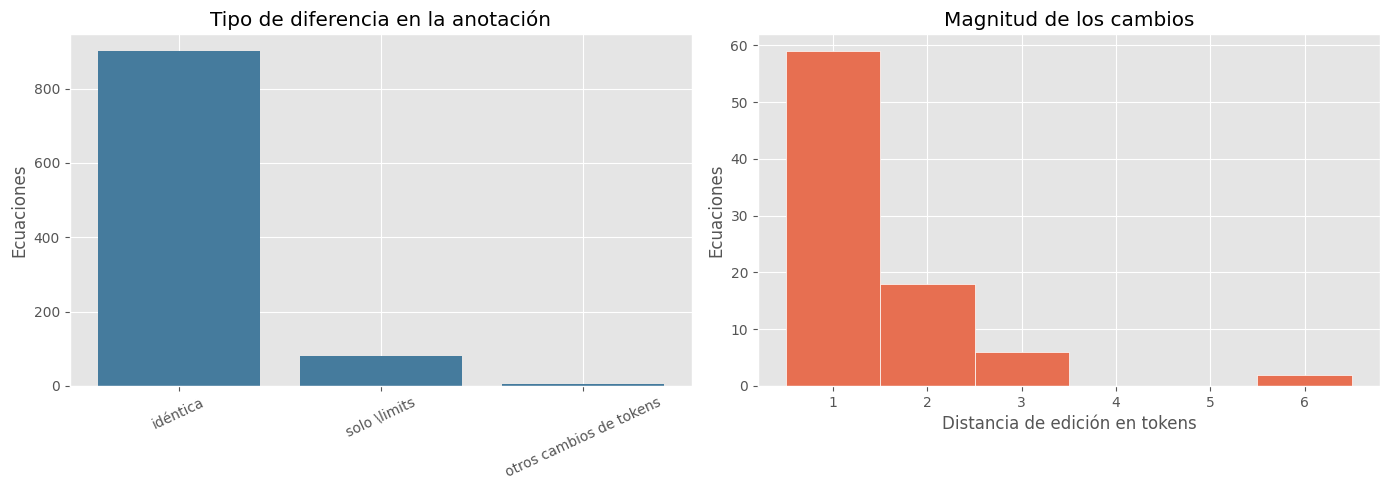

In [10]:
diferencias_anotacion = comparacion.loc[
    ~comparacion["tokens_iguales"],
    [
        "id", "latex_modelo1", "latex_modelo2",
        "n_tokens_modelo1", "n_tokens_modelo2",
        "delta_n_tokens", "distancia_tokens",
        "tipo_diferencia", "operaciones",
    ],
].sort_values(["distancia_tokens", "id"], ascending=[False, True])

display(diferencias_anotacion.head(25))

otros_cambios = diferencias_anotacion.loc[
    diferencias_anotacion["tipo_diferencia"] == "otros cambios de tokens"
]
print(f"Cambios no explicados únicamente por \\limits: {len(otros_cambios)}")
display(otros_cambios)

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
conteo_plot = comparacion["tipo_diferencia"].value_counts()
ejes[0].bar(conteo_plot.index, conteo_plot.values, color="#457b9d")
ejes[0].set(ylabel="Ecuaciones", title="Tipo de diferencia en la anotación")
ejes[0].tick_params(axis="x", rotation=25)

distancias = comparacion.loc[
    comparacion["distancia_tokens"] > 0, "distancia_tokens"
]
if len(distancias):
    bins = np.arange(0.5, distancias.max() + 1.5, 1)
    ejes[1].hist(distancias, bins=bins, color="#e76f51", edgecolor="white")
ejes[1].set(
    xlabel="Distancia de edición en tokens",
    ylabel="Ecuaciones",
    title="Magnitud de los cambios",
)
fig.tight_layout()
plt.show()


In [11]:
# Resumen de operaciones y tokens involucrados.
conteo_operaciones = Counter()
inserciones = Counter()
eliminaciones = Counter()
sustituciones = Counter()

for operaciones in comparacion["operaciones"]:
    for op in operaciones:
        conteo_operaciones[op["operacion"]] += 1
        if op["operacion"] == "insert":
            inserciones.update(op["tokens_modelo2"])
        elif op["operacion"] == "delete":
            eliminaciones.update(op["tokens_modelo1"])
        elif op["operacion"] == "replace":
            eliminaciones.update(op["tokens_modelo1"])
            inserciones.update(op["tokens_modelo2"])
            sustituciones[(tuple(op["tokens_modelo1"]), tuple(op["tokens_modelo2"]))] += 1

display(pd.Series(conteo_operaciones, name="bloques").to_frame())
display(
    pd.DataFrame(inserciones.most_common(20), columns=["token_insertado_en_modelo2", "frecuencia"])
)
display(
    pd.DataFrame(eliminaciones.most_common(20), columns=["token_eliminado_de_modelo1", "frecuencia"])
)

if sustituciones:
    tabla_sustituciones = pd.DataFrame(
        [
            {
                "modelo1": " ".join(origen),
                "modelo2": " ".join(destino),
                "frecuencia": frecuencia,
            }
            for (origen, destino), frecuencia in sustituciones.most_common()
        ]
    )
    display(tabla_sustituciones.head(20))


,bloques
insert,107
replace,1
delete,12


,token_insertado_en_modelo2,frecuencia
0,\limits,105
1,},2
2,\Pi,1


,token_eliminado_de_modelo1,frecuencia
0,},7
1,_,5
2,{,5
3,\pi,1


,modelo1,modelo2,frecuencia
0,\pi,\Pi,1


## 4. Comparación del vocabulario y sus proporciones

Aunque dos tests compartan las mismas expresiones matemáticas, un cambio sistemático de tokenización o de comandos LaTeX altera el vocabulario objetivo y la longitud de las secuencias. Se comparan frecuencia absoluta, proporción y presencia por ecuación.


In [12]:
contador_m1 = Counter(
    token for tokens in comparacion["tokens_modelo1"] for token in tokens
)
contador_m2 = Counter(
    token for tokens in comparacion["tokens_modelo2"] for token in tokens
)
total_m1 = sum(contador_m1.values())
total_m2 = sum(contador_m2.values())
vocabulario = sorted(set(contador_m1) | set(contador_m2))

comparacion_tokens = pd.DataFrame({"token": vocabulario})
comparacion_tokens["frecuencia_modelo1"] = comparacion_tokens["token"].map(contador_m1).fillna(0).astype(int)
comparacion_tokens["frecuencia_modelo2"] = comparacion_tokens["token"].map(contador_m2).fillna(0).astype(int)
comparacion_tokens["proporcion_modelo1"] = comparacion_tokens["frecuencia_modelo1"] / total_m1
comparacion_tokens["proporcion_modelo2"] = comparacion_tokens["frecuencia_modelo2"] / total_m2
comparacion_tokens["delta_frecuencia"] = (
    comparacion_tokens["frecuencia_modelo2"]
    - comparacion_tokens["frecuencia_modelo1"]
)
comparacion_tokens["delta_proporcion"] = (
    comparacion_tokens["proporcion_modelo2"]
    - comparacion_tokens["proporcion_modelo1"]
)
comparacion_tokens["presente_solo_en"] = np.select(
    [
        comparacion_tokens["frecuencia_modelo1"].eq(0),
        comparacion_tokens["frecuencia_modelo2"].eq(0),
    ],
    ["Modelo2", "Modelo1"],
    default="ambos",
)

cambios_tokens = comparacion_tokens.loc[
    comparacion_tokens["delta_frecuencia"] != 0
].copy()
cambios_tokens["magnitud_cambio"] = cambios_tokens["delta_frecuencia"].abs()
cambios_tokens = cambios_tokens.sort_values(
    ["magnitud_cambio", "token"], ascending=[False, True]
)

display(
    pd.Series(
        {
            "tokens totales Modelo1": total_m1,
            "tokens totales Modelo2": total_m2,
            "vocabulario Modelo1": len(contador_m1),
            "vocabulario Modelo2": len(contador_m2),
            "vocabulario compartido": len(set(contador_m1) & set(contador_m2)),
            "tokens solo en Modelo1": len(set(contador_m1) - set(contador_m2)),
            "tokens solo en Modelo2": len(set(contador_m2) - set(contador_m1)),
            "tipos cuya frecuencia cambia": len(cambios_tokens),
        },
        name="valor",
    ).to_frame()
)
display(cambios_tokens.head(30))


,valor
tokens totales Modelo1,15897
tokens totales Modelo2,15987
vocabulario Modelo1,108
vocabulario Modelo2,110
vocabulario compartido,108
tokens solo en Modelo1,0
tokens solo en Modelo2,2
tipos cuya frecuencia cambia,6


,token,frecuencia_modelo1,frecuencia_modelo2,proporcion_modelo1,proporcion_modelo2,delta_frecuencia,delta_proporcion,presente_solo_en,magnitud_cambio
60,\limits,0,105,0.000000,0.006568,105,0.006568,Modelo2,105
80,_,630,625,0.039630,0.039094,-5,-0.000536,ambos,5
107,{,2297,2292,0.144493,0.143366,-5,-0.001126,ambos,5
109,},2297,2292,0.144493,0.143366,-5,-0.001126,ambos,5
41,\Pi,0,1,0.000000,0.000063,1,0.000063,Modelo2,1
65,\pi,68,67,0.004278,0.004191,-1,-0.000087,ambos,1


,valor
distancia de variación total,0.006630
divergencia Jensen-Shannon (bits),0.003324


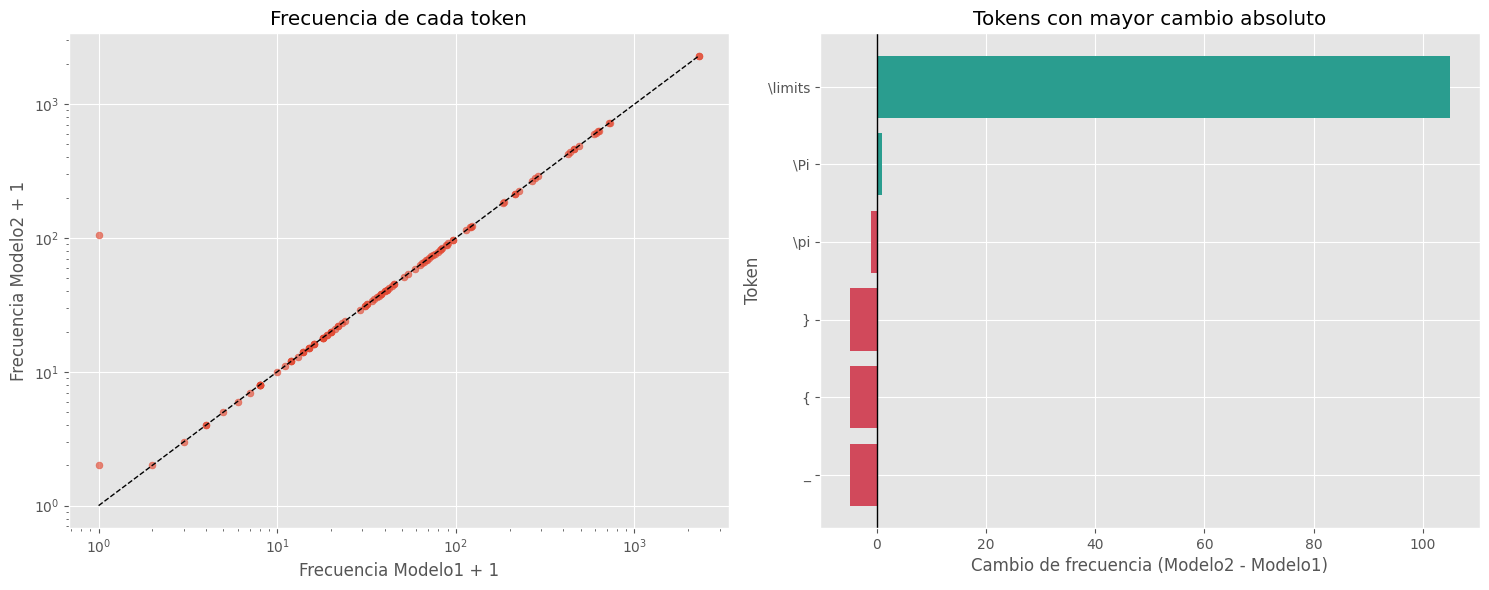

In [13]:
# Distancia de variación total y divergencia Jensen-Shannon.
p = comparacion_tokens["proporcion_modelo1"].to_numpy(dtype=float)
q = comparacion_tokens["proporcion_modelo2"].to_numpy(dtype=float)
m = 0.5 * (p + q)

def kl_segura(a, b):
    mascara = a > 0
    return float(np.sum(a[mascara] * np.log2(a[mascara] / b[mascara])))

variacion_total = 0.5 * np.abs(p - q).sum()
jensen_shannon = 0.5 * kl_segura(p, m) + 0.5 * kl_segura(q, m)

display(
    pd.Series(
        {
            "distancia de variación total": variacion_total,
            "divergencia Jensen-Shannon (bits)": jensen_shannon,
        },
        name="valor",
    ).to_frame().round(8)
)

fig, ejes = plt.subplots(1, 2, figsize=(15, 6))
ejes[0].scatter(
    comparacion_tokens["frecuencia_modelo1"] + 1,
    comparacion_tokens["frecuencia_modelo2"] + 1,
    alpha=0.65,
    s=24,
)
maximo = max(
    comparacion_tokens["frecuencia_modelo1"].max(),
    comparacion_tokens["frecuencia_modelo2"].max(),
) + 1
ejes[0].plot([1, maximo], [1, maximo], "--", color="black", linewidth=1)
ejes[0].set_xscale("log")
ejes[0].set_yscale("log")
ejes[0].set(
    xlabel="Frecuencia Modelo1 + 1",
    ylabel="Frecuencia Modelo2 + 1",
    title="Frecuencia de cada token",
)

top_cambios = cambios_tokens.head(20).sort_values("delta_frecuencia")
colores = ["#d1495b" if x < 0 else "#2a9d8f" for x in top_cambios["delta_frecuencia"]]
ejes[1].barh(top_cambios["token"], top_cambios["delta_frecuencia"], color=colores)
ejes[1].axvline(0, color="black", linewidth=1)
ejes[1].set(
    xlabel="Cambio de frecuencia (Modelo2 - Modelo1)",
    ylabel="Token",
    title="Tokens con mayor cambio absoluto",
)
fig.tight_layout()
plt.show()


## 5. Vista conjunta: imágenes y anotaciones

Esta tabla cruza ambos ejes. Permite comprobar si una muestra cambia visualmente, simbólicamente, en ambos aspectos o en ninguno.


In [14]:
comparacion_conjunta = comparacion.merge(
    comparacion_imagenes[
        [
            "id", "archivo_modelo1", "archivo_modelo2",
            "hash_igual", "pixeles_iguales", "mismas_dimensiones",
        ]
    ],
    on="id",
    how="outer",
    validate="one_to_one",
)
comparacion_conjunta["estado_conjunto"] = np.select(
    [
        comparacion_conjunta["pixeles_iguales"].eq(True)
        & comparacion_conjunta["tokens_iguales"].eq(True),
        comparacion_conjunta["pixeles_iguales"].eq(True)
        & comparacion_conjunta["tokens_iguales"].eq(False),
        comparacion_conjunta["pixeles_iguales"].eq(False)
        & comparacion_conjunta["tokens_iguales"].eq(True),
        comparacion_conjunta["pixeles_iguales"].eq(False)
        & comparacion_conjunta["tokens_iguales"].eq(False),
    ],
    [
        "imagen y anotación iguales",
        "imagen igual, anotación diferente",
        "imagen diferente, anotación igual",
        "imagen y anotación diferentes",
    ],
    default="pareja incompleta",
)

resumen_conjunto = (
    comparacion_conjunta["estado_conjunto"]
    .value_counts(dropna=False)
    .rename("cantidad")
    .to_frame()
)
resumen_conjunto["proporcion"] = resumen_conjunto["cantidad"] / len(comparacion_conjunta)
display(resumen_conjunto.style.format({"proporcion": "{:.2%}"}))

display(
    comparacion_conjunta.loc[
        comparacion_conjunta["estado_conjunto"] != "imagen y anotación iguales",
        [
            "id", "estado_conjunto", "tipo_diferencia",
            "latex_modelo1", "latex_modelo2",
        ],
    ].head(30)
)


,cantidad,proporcion
estado_conjunto,,
imagen y anotación iguales,901,91.38%
"imagen igual, anotación diferente",85,8.62%


,id,estado_conjunto,tipo_diferencia,latex_modelo1,latex_modelo2
20,18_em_5,"imagen igual, anotación diferente",solo \limits,\int g = \lim _ { n \rightarrow \infty } \int g _ { n },\int g = \lim \limits _ { n \rightarrow \infty } \int g _ { n }
59,23_em_59,"imagen igual, anotación diferente",solo \limits,\sum _ { r = 1 } ^ { n } a r ^ { b } = a \sum _ { r = 1 } ^ { n } r ^ { b },\sum \limits _ { r = 1 } ^ { n } a r ^ { b } = a \sum \limits _ { r = 1 } ^ { n } r ^ { b }
72,23_em_72,"imagen igual, anotación diferente",solo \limits,\sum _ { i = 1 } ^ { n } x _ { n } = \sum _ { i = 1 } ^ { n } y _ { n },\sum \limits _ { i = 1 } ^ { n } x _ { n } = \sum \limits _ { i = 1 } ^ { n } y _ { n }
76,26_em_77,"imagen igual, anotación diferente",solo \limits,x ^ { i } e _ { i } = \sum _ { i } x ^ { i } e _ { i },x ^ { i } e _ { i } = \sum \limits _ { i } x ^ { i } e _ { i }
83,26_em_84,"imagen igual, anotación diferente",solo \limits,S _ { \infty } = \lim _ { n \rightarrow \infty } \frac { a ( 1 - r ^ { n } ) } { 1 - r } = \frac { a } { 1 - r },S _ { \infty } = \lim \limits _ { n \rightarrow \infty } \frac { a ( 1 - r ^ { n } ) } { 1 - r } = \frac { a } { 1 - r }
101,27_em_102,"imagen igual, anotación diferente",solo \limits,\lim _ { a \rightarrow \infty } f ( a ),\lim \limits _ { a \rightarrow \infty } f ( a )
125,28_em_126,"imagen igual, anotación diferente",solo \limits,\frac { \sum _ { k = 1 } ^ { N } k ^ { 2 } } { a },\frac { \sum \limits _ { k = 1 } ^ { N } k ^ { 2 } } { a }
143,28_em_144,"imagen igual, anotación diferente",solo \limits,\sum _ { i } k _ { i },\sum \limits _ { i } k _ { i }
160,29_em_161,"imagen igual, anotación diferente",solo \limits,f ( z _ { 0 } ) = \lim _ { z \rightarrow z _ { 0 } } f ( z ),f ( z _ { 0 } ) = \lim \limits _ { z \rightarrow z _ { 0 } } f ( z )
169,29_em_171,"imagen igual, anotación diferente",solo \limits,\lim _ { t \rightarrow c } a _ { 1 } ( t ) = a _ { 1 },\lim \limits _ { t \rightarrow c } a _ { 1 } ( t ) = a _ { 1 }


## 6. Exportación y síntesis automática

Se guardan tablas que permiten auditar cada diferencia sin volver a procesar las imágenes:

- \`comparacion_pareada_modelo1_modelo2.csv\`
- \`diferencias_anotaciones_modelo1_modelo2.csv\`
- \`comparacion_tokens_modelo1_modelo2.csv\`
- \`comparacion_imagenes_modelo1_modelo2.csv\`
- \`resumen_comparacion_modelo1_modelo2.json\`


In [15]:
def serializar_operaciones(ops):
    return json.dumps(ops, ensure_ascii=False)

export_conjunta = comparacion_conjunta.copy()
for columna in ["tokens_modelo1", "tokens_modelo2"]:
    if columna in export_conjunta:
        export_conjunta[columna] = export_conjunta[columna].map(
            lambda xs: " ".join(xs) if isinstance(xs, list) else xs
        )
if "operaciones" in export_conjunta:
    export_conjunta["operaciones"] = export_conjunta["operaciones"].map(
        lambda ops: serializar_operaciones(ops) if isinstance(ops, list) else ops
    )

export_conjunta.to_csv(
    RESULTADOS_DIR / "comparacion_pareada_modelo1_modelo2.csv",
    index=False,
    encoding="utf-8",
)

export_diferencias = diferencias_anotacion.copy()
export_diferencias["operaciones"] = export_diferencias["operaciones"].map(
    serializar_operaciones
)
export_diferencias.to_csv(
    RESULTADOS_DIR / "diferencias_anotaciones_modelo1_modelo2.csv",
    index=False,
    encoding="utf-8",
)
comparacion_tokens.to_csv(
    RESULTADOS_DIR / "comparacion_tokens_modelo1_modelo2.csv",
    index=False,
    encoding="utf-8",
)
comparacion_imagenes.to_csv(
    RESULTADOS_DIR / "comparacion_imagenes_modelo1_modelo2.csv",
    index=False,
    encoding="utf-8",
)

resumen_final = {
    "dataset": "CROHME 2014 test",
    "modelos": ["Modelo1", "Modelo2"],
    "inventario": {
        "ids_union": int(len(todos_ids)),
        "ids_comunes_cuatro_fuentes": int(
            len(ids_cap_m1 & ids_cap_m2 & ids_img_m1 & ids_img_m2)
        ),
        "ids_misma_posicion": int(comparacion["misma_posicion"].sum()),
    },
    "imagenes": {
        "pares_comparados": int(len(comparacion_imagenes)),
        "archivos_sha256_iguales": int(comparacion_imagenes["hash_igual"].sum()),
        "pares_pixeles_iguales": int(comparacion_imagenes["pixeles_iguales"].sum()),
        "pares_visualmente_diferentes": int(
            (~comparacion_imagenes["pixeles_iguales"]).sum()
        ),
    },
    "anotaciones": {
        "pares_comparados": int(len(comparacion)),
        "texto_exacto_igual": int(comparacion["texto_exacto_igual"].sum()),
        "tokens_iguales": int(comparacion["tokens_iguales"].sum()),
        "tokens_diferentes": int((~comparacion["tokens_iguales"]).sum()),
        "diferencias_solo_limits": int(
            (comparacion["tipo_diferencia"] == r"solo \limits").sum()
        ),
        "otros_cambios_tokens": int(
            (comparacion["tipo_diferencia"] == "otros cambios de tokens").sum()
        ),
        "distancia_edicion_total": int(comparacion["distancia_tokens"].sum()),
        "distancia_edicion_maxima": int(comparacion["distancia_tokens"].max()),
    },
    "vocabulario": {
        "tokens_totales_modelo1": int(total_m1),
        "tokens_totales_modelo2": int(total_m2),
        "tipos_modelo1": int(len(contador_m1)),
        "tipos_modelo2": int(len(contador_m2)),
        "variacion_total": float(variacion_total),
        "jensen_shannon_bits": float(jensen_shannon),
    },
}

with (
    RESULTADOS_DIR / "resumen_comparacion_modelo1_modelo2.json"
).open("w", encoding="utf-8") as archivo:
    json.dump(resumen_final, archivo, ensure_ascii=False, indent=2)

print("Síntesis:")
print(
    f"- Imágenes: {resumen_final['imagenes']['archivos_sha256_iguales']} de "
    f"{resumen_final['imagenes']['pares_comparados']} son idénticas byte a byte."
)
print(
    f"- Anotaciones: {resumen_final['anotaciones']['tokens_diferentes']} de "
    f"{resumen_final['anotaciones']['pares_comparados']} difieren en tokens."
)
print(
    rf"- Diferencias explicadas sólo por \limits: "
    f"{resumen_final['anotaciones']['diferencias_solo_limits']}."
)
print("\nArchivos generados:")
for ruta in sorted(RESULTADOS_DIR.glob("*modelo1_modelo2*")):
    print(f"- {ruta.name} ({ruta.stat().st_size:,} bytes)")


Síntesis:
- Imágenes: 986 de 986 son idénticas byte a byte.
- Anotaciones: 85 de 986 difieren en tokens.
- Diferencias explicadas sólo por \limits: 79.

Archivos generados:
- comparacion_imagenes_modelo1_modelo2.csv (231,949 bytes)
- comparacion_pareada_modelo1_modelo2.csv (389,401 bytes)
- comparacion_tokens_modelo1_modelo2.csv (9,447 bytes)
- diferencias_anotaciones_modelo1_modelo2.csv (25,409 bytes)
- resumen_comparacion_modelo1_modelo2.json (909 bytes)


### Guía de interpretación

- **Hash igual** implica que los BMP son exactamente el mismo archivo, no sólo una imagen visualmente parecida.
- **Imagen igual y anotación diferente** señala una transformación del objetivo LaTeX, no una diferencia en la entrada visual.
- \`\limits\` controla dónde se dibujan subíndices y superíndices de operadores grandes; su presencia cambia la secuencia objetivo y puede afectar métricas exactas aunque la expresión conserve esencialmente el mismo significado.
- El orden distinto de los archivos no afecta una evaluación basada en ID, pero sí puede causar comparaciones incorrectas si se alinean filas sólo por posición.
- Para entrenamiento o evaluación conjunta conviene escoger una convención de anotación y normalizarla explícitamente, conservando siempre los IDs originales para trazabilidad.
